## Comparing Linear vs. Binary vs. Interpolation Search

Programmer: Katie de la Pena

Summary: The purpose of this Jupyter Notebook is to compare the runtimes of different algorithms to determine which one is most efficent. By using Python's timeit module, we calculate the process times for binary search, linear search, and interpolation search using input size of size N, repeated trials (3) times, with sample iterations (1000) in each trial.

IN: This program does not take any input

OUTPUT: Results are printed to the console, as well as stored in a .csv file (N, Algorithms, Minimum Search Time) and used in graphs

Example Output:
<pre> - (Use of Google Gemini AI to figure out how to indent block of text)
        N,Algorithm,Minimum Search Time
        1000,Binary Search,8.520000000089567e-07
        1000,Linear Search,9.68599999998787e-06
        1000,Interpolation Search,4.4400000001587616e-07
        100000,Binary Search,1.4039999999795327e-06
        100000,Linear Search,0.0007641039999999748
        100000,Interpolation Search,4.519999999956781e-07
        1000000,Binary Search,2.217000000086955e-06
        1000000,Linear Search,0.008085661999999957
        1000000,Interpolation Search,3.859999999349384e-07
        10000000,Binary Search,2.78600000001461e-06
        10000000,Linear Search,0.0816852429999999
        10000000,Interpolation Search,4.7299999982897136e-07

        MIN Interpolation Search Time:  4.44000000e-07
        AVG Interpolation Search Time:  4.52333333e-07
        MAX Interpolation Search Time:  4.67000000e-07
</pre>

## Binary Search

Binary Search is an algorithm that is used to find a position of a designated value in an sorted list. This is done by consistently splitting the list in halves, eliminating the side the value can not be in. 

Steps to Binary Search:
1.  Divide List in half and find middle index (position)
2.  Check if number at the middle index is designated value to find
3.  If number is at middle index, return position found
4.  If it is not, check if designated value is less than or greater than value at middle position
    * If is it less than middle value, look at the left half of the list in next search
    * If it is greater than middle value, look at the right half of the list in next search
5. Continue search until desginated value is found, if not, return -1

Source: (https://www.geeksforgeeks.org/dsa/binary-search/)

In [115]:
#---------------------------\
# binary_search()  \
# Function that uses the binary search algorithim to find a desired value in a list
# IN: mylist - A list of numbers, find - designated number value to search for
# RETURNS: middlePosition - position designated value was found at, -1 - desginated value not found
#---------------------------\
def binary_search(mylist : list, find : int) -> int:
    """Function that uses binary search to find a specific value in a list"""

    # Establish lowest index value (0) and highest index value (length of list)
    low = 0
    high = len(mylist) - 1

    # Search until no halves left to search
    while low <= high:
         # Establish middle index and value at that index
         middlePosition = (high + low) // 2
         middleNumber = mylist[middlePosition]

        # Return position if find is equal to the number at that position
         if find == middleNumber:
             return middlePosition
         # If find is less than middle value, look at left half of list
         elif find < middleNumber:
             high = middlePosition - 1
        # If find is greater than middle value, look at right half of list
         else: 
             low = middlePosition + 1

    # Return -1 if number is not found
    return -1

# end binary_search()

## Linear Search

Linear Search is an algorithm that checks every value from the beginning of a list to the end of a list to find a designated value and returns the position that value is found at. It is one of the simplest search methods.

Steps to Linear Search: 
1. Set current position of list to 0
2. Iterate through list until current position is equal to max position (highest possible index in list)
3. If the value at any point in the iteration is equal to the designated number, return the value it was found at
4. If the designated value could not be found in the list, return -1

Source: (https://www.geeksforgeeks.org/dsa/linear-search/)

In [116]:
#---------------------------\
# linear_search()  \
# Function that uses the linear search algorithim to find a desired value in a list
# IN: mylist - A list of numbers, find - designated number value to search for
# RETURNS: middlePosition - position designated value was found at, -1 - desginated value not found
#---------------------------\
def linear_search(mylist : list, find : int) -> int:
    """Function that uses linear search to find a number in a list"""

    # Set currentPosition equal to 0 and set max position to highest possible index value
    # which is length of list - 1
    currentPosition = 0
    maxPosition = len(mylist) - 1

    # Continue iteration through loop until all numbers searches
    while currentPosition <= maxPosition:
        currentNumber = mylist[currentPosition]

        # If find is found, return its position
        if currentNumber == find:
            return currentPosition

        # Add 1 to position to search next value
        currentPosition += 1

    # Return -1 if not found
    return -1

# end linear_search()

## Interpolation Search

Interpolation Search is an improvement over Binary Search, as it constructs new data points within the range of a discrete set of data points. It compares to binary search by not always looking at the middle index value, interpolation search looks at different index values based on the intendend value to find.

Steps to Interpolation Search:
1. Initalize boundaries (set low = 0 and high being equal to number of items in a list)
2. Calculate probe position using linear interpolation formula
* pos = low + [(target - list[low] x (high - low))/ (list[high] - list[low])]
3. Identify if target is found at index
* If it is, return index found at
* If it is less than value at index, look towards left side of probe
* If it is greater than value at index, look towards right side of probe
4. Continue loop until value is found or return -1 if it is not found.

Source: (https://www.geeksforgeeks.org/dsa/interpolation-search/)

In [ ]:
#---------------------------\
# interpolation_search()  \
# Function that uses an interpolation search algorithm to find a desired value in a list
# IN: mylist - List of numbers (ints), find - int value to search for
# RETURNS: int - either the position find was found at or -1 if not found
#---------------------------\
def interpolation_search(mylist : list, find : int) -> int:
    """Function that uses interpolation search to find number in a list"""

    # Set lowest index equal to 0 and highest index equal to length of list - 1
    low = 0
    high = len(mylist) - 1

    # While lowest index value does not exceed highest index value and find is in the range of values
    while low <= high and find >= mylist[low] and find <= mylist[high]:
        if mylist[low] == mylist[high]:
            # Avoid division by 0
            if mylist[low] == find:
                return low

            return -1

        # Interpolation probe equation (Google Gemini AI)
        pos = low + int(
            (find - mylist[low]) * (high - low) / (mylist[high] - mylist[low])
        )

        # set probe number equal to value at index calculated before
        posNumber = mylist[pos]

        # Similar to binary search, if find is found, return position
        if posNumber == find:
            return pos
        # If find is less than number at probe index, look to left
        elif find < posNumber:
            high = pos - 1
        # If find is greater than number at probe index, look to right
        else:
            low = pos + 1

    # Return -1 if number not found in list
    return -1

# end interpolation_search()

## Testing differences between Linear and Binary Search Run Times

To test the efficency of both algorithms, we must first set up a function to compute search times given the size of a list, how many trials to run, and how many times it should be ran in each trial (samples). The function then returns average estimated single run times to be used for calculations.

#### Setup .csv file for reporting times

In [ ]:
# Use of Google Gemini AI here for help - create csv and write header line 
import csv

CSV_Filename = "macbookPro_search_results.csv"

header = ["N", "Algorithm", "Minimum Search Time"]

with open(CSV_Filename, mode = "w", newline = "") as file:
    writer = csv.writer(file)
    writer.writerow(header)

#### Binary and Linear Search Timing Functions

In [ ]:
# import the required modules
import time
import timeit

#---------------------------\
# binary_time()  \
# Function that times how long the processing time is for a  binary search to find a 
# random value in a list of length N
# IN: N - int of values in each list, trials - int of how many times expierment is repeated,
# sample - int of number of times binary_search ran in each trial
# RETURNS: run_times - a list of the average single search time in each trial
#---------------------------\
def binary_time(N : int, trials : int, samples : int) -> list:
    """Function that tests the processing time of the binary_search function"""
    # Setup code before testing binary_search function: create list of size {N} and sort list 
    # Sorting is NECESSARY for binary_search and done in setup to avoid being calculated in process time
    SETUP_CODE = f'''
from __main__ import binary_search
from random import randint
mylist = [x for x in range({N})]
mylist.sort()'''

    # Code that is repeated throughout experiment, what is being timed
    TEST_CODE = '''
find = randint(0, len(mylist) - 1)
binary_search(mylist, find)'''

    times = timeit.repeat(setup = SETUP_CODE,
                              stmt = TEST_CODE,
                              timer = time.process_time,
                              repeat = trials,
                              number = samples)

    # Store average single run times of each trial
    run_times = []
    for t in times:
        # To identify average single search time in each trial, divide by samples
        singleSearchTime = t / samples
        run_times.append(singleSearchTime)

    # Calculate descriptive stats
    minimumSearchTime = min(run_times)
    averageSearchTime = sum(run_times) / len(run_times)
    maximumSearchTime = max(run_times)

    # Print descriptive stats
    print(f"MIN Binary Search Time: {minimumSearchTime: .8e} seconds")
    print(f"AVG Binary Search Time: {averageSearchTime: .8e} seconds")
    print(f"MAX Binary Search Time: {maximumSearchTime: .8e} seconds")

    # Store results in csv file for specific computer (Minimum Search Time being used in graphs)
    with open('macbookPro_search_results.csv', mode = 'a', newline = '') as file:
             writer = csv.writer(file)
             writer.writerow([N, 'Binary Search', minimumSearchTime])

    return run_times

# end binary_time()

#---------------------------\
# linear_time()  \
# Function that times how long the processing time is for a  binary search to find a 
# random value in a list of length N
# IN: N - number of values in each list, trials - how many times expierment is repeated,
# sample - number of times binary_search ran in each trial
# RETURNS: run_times - a list of the average single search time in each trial
#---------------------------\
def linear_time(N, trials, samples):
    """Function that tests the process time of the linear_search function"""

    # Setup code before testing binary_search function: create list of size {N}
    SETUP_CODE = f'''
from __main__ import linear_search
from random import randint
mylist = [x for x in range({N})]'''

     # Code that is repeated throughout experiment, what is being timed
    TEST_CODE = '''
find = randint(0, len(mylist) - 1)
linear_search(mylist, find)
    '''
    # timeit.repeat statement
    # Times refer to TIME for each TRIAL
    times = timeit.repeat(setup = SETUP_CODE,
                          stmt = TEST_CODE,
                          timer = time.process_time,
                          repeat = trials,
                          number = samples)


    # Store average single search times for all trials
    run_times = []
    for t in times:
            # To identify average single search time in each trial, divide by samples
            singleSearchTime = t / samples
            # Append times to run_times
            run_times.append(singleSearchTime)


    # Calculate descriptive stats
    minimumSearchTime = min(run_times)
    averageSearchTime = sum(run_times) / len(run_times)
    maximumSearchTime = max(run_times)

    # Print descriptive stats
    print(f"MIN Linear Search Time: {minimumSearchTime: .8e} seconds")
    print(f"AVG Linear Search Time: {averageSearchTime: .8e} seconds")
    print(f"MAX Linear Search Time: {maximumSearchTime: .8e} seconds")

    # Write minimum single search time across all trials to .csv file
    with open('macbookPro_search_results.csv', mode = 'a', newline = '') as file:
         writer = csv.writer(file)
         writer.writerow([N, 'Linear Search', minimumSearchTime])


    return run_times

# end linear_time()

#---------------------------\
# interpolation_time()  \
# Function that times how long the processing time of interpolation_search is
# IN:  N - number of values in each list, trials - how many times expierment is repeated,
# sample - number of times binary_search ran in each trial
# RETURNS: run_times - a list of the average single search time in each trial
#---------------------------\
def interpolation_time(N : int, trials : int, samples : int) -> list:
    """Function that calculates the processing time of interpolation_search"""

    # Setup code before testing binary_search function: create list of size {N}
    # Like binary_search(), the list must also be sorted
    SETUP_CODE = f'''
from __main__ import interpolation_search
from random import randint
mylist = [x for x in range({N})]
mylist.sort()'''

    # Code that is repeated throughout experiment, what is being timed
    TEST_CODE = '''
find = randint(0, len(mylist) - 1)
interpolation_search(mylist, find)
'''

    # timeit.repeat statement
    # Times refer to TIME for each TRIAL
    times = timeit.repeat(setup=SETUP_CODE,
                          stmt=TEST_CODE,
                          timer=time.process_time,
                          repeat=trials,
                          number=samples)
    

    # Store average single search times for all trials
    run_times = []
    for t in times:
        # To identify average single search time in each trial, divide by samples
        singleSearchTime = t / samples
        run_times.append(singleSearchTime)

    # Compute descriptive stats
    minimumSearchTime = min(run_times)
    averageSearchTime = sum(run_times) / len(run_times)
    maximumSearchTime = max(run_times)

    # Print stats to console
    print(f"MIN Interpolation Search Time: {minimumSearchTime: .8e} seconds")
    print(f"AVG Interpolation Search Time: {averageSearchTime: .8e} seconds")
    print(f"MAX Interpolation Search Time: {maximumSearchTime: .8e} seconds")

    # Write minimum search time to .csv file
    with open(CSV_Filename, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([N, 'Interpolation Search', minimumSearchTime])

    return run_times

# end interpolation_time()


## Experimental Timing Tests

Now, to compare the three algorithms we must test their processing times across lists of very lengths, as algorithms can become less efficent as list size increases. To compare, we first look at a list size of 10^3 (1000), then 10^5 (100,000), then 10^6 (1,000,000), and lastly 10^7 (10,000,000). To ensure the experiment works, the code blocks that establish the variables must be ran before calling and of the algorithm time functions. 

#### 1. N = 1000, Sample = 1000, Trials = 3
##### List Length = (10^3)


In [ ]:
# Establish variables, RUN FIRST
N = 1000
samples = 1000
trials = 3

In [120]:
binary_time(N, trials, samples)

MIN Binary Search Time:  8.52000000e-07
AVG Binary Search Time:  8.85000000e-07
MAX Binary Search Time:  9.47000000e-07


[9.469999999964785e-07, 8.520000000089567e-07, 8.559999999988577e-07]

In [121]:
linear_time(N, trials, samples)

MIN Linear Search Time:  9.68600000e-06
AVG Linear Search Time:  1.20083333e-05
MAX Linear Search Time:  1.38020000e-05


[1.380200000005516e-05, 1.2537000000065745e-05, 9.68599999998787e-06]

In [122]:
interpolation_time(N, trials, samples)

MIN Interpolation Search Time:  4.44000000e-07
AVG Interpolation Search Time:  4.52333333e-07
MAX Interpolation Search Time:  4.67000000e-07


[4.6699999995780673e-07, 4.460000000108266e-07, 4.4400000001587616e-07]

#### 2. N = 100,000, Sample = 1000, Trials = 3
##### List Length(10^5)

In [ ]:
# Establish variables, RUN FIRST
N = 100_000
samples = 1000
trials = 3

In [124]:
binary_time(N, trials, samples)

MIN Binary Search Time:  1.40400000e-06
AVG Binary Search Time:  1.59100000e-06
MAX Binary Search Time:  1.86300000e-06


[1.506000000063068e-06, 1.8630000000712245e-06, 1.4039999999795327e-06]

In [125]:
linear_time(N, trials, samples)

MIN Linear Search Time:  7.64104000e-04
AVG Linear Search Time:  7.93523000e-04
MAX Linear Search Time:  8.16040000e-04


[0.0007641039999999748, 0.0008160399999999299, 0.0008004250000000183]

In [126]:
interpolation_time(N, trials, samples)

MIN Interpolation Search Time:  4.52000000e-07
AVG Interpolation Search Time:  6.00333333e-07
MAX Interpolation Search Time:  8.68000000e-07


[4.519999999956781e-07, 8.679999999685606e-07, 4.81000000036147e-07]

##### 3. N = 1,000,000 , Sample = 1000, Trials = 3
##### List Length = (10^6)

In [ ]:
# Establish variables, RUN FIRST
N = 1_000_000
samples = 1000
trials = 3

In [128]:
binary_time(N, trials, samples)

MIN Binary Search Time:  2.21700000e-06
AVG Binary Search Time:  2.45000000e-06
MAX Binary Search Time:  2.66000000e-06


[2.659999999991669e-06, 2.4730000000090513e-06, 2.217000000086955e-06]

In [129]:
linear_time(N, trials, samples)

MIN Linear Search Time:  8.08566200e-03
AVG Linear Search Time:  8.17999900e-03
MAX Linear Search Time:  8.25074400e-03


[0.008250744000000055, 0.008085661999999957, 0.008203591000000074]

In [130]:
interpolation_time(N, trials, samples)

MIN Interpolation Search Time:  3.86000000e-07
AVG Interpolation Search Time:  4.39333333e-07
MAX Interpolation Search Time:  4.70000000e-07


[4.700000000639193e-07, 4.619999999704305e-07, 3.859999999349384e-07]

#### 4. N = 10,000,000 , Sample = 1000, Trials = 3
##### List Length = (10^7)

In [ ]:
# Establish variables, RUN FIRST
N = 10_000_000
samples = 1000
trials = 3

In [132]:
binary_time(N, trials, samples)

MIN Binary Search Time:  2.78600000e-06
AVG Binary Search Time:  2.81566667e-06
MAX Binary Search Time:  2.84900000e-06


[2.78600000001461e-06, 2.848999999969237e-06, 2.8119999999489666e-06]

In [133]:
linear_time(N, trials, samples)

MIN Linear Search Time:  8.16852430e-02
AVG Linear Search Time:  8.23775023e-02
MAX Linear Search Time:  8.31834290e-02


[0.08226383499999997, 0.08318342900000004, 0.0816852429999999]

In [134]:
interpolation_time(N, trials, samples)

MIN Interpolation Search Time:  4.73000000e-07
AVG Interpolation Search Time:  4.81333333e-07
MAX Interpolation Search Time:  4.86000000e-07


[4.8600000013721e-07, 4.849999997986743e-07, 4.7299999982897136e-07]

## Plot Results on Graph

#### Macbook Pro Results

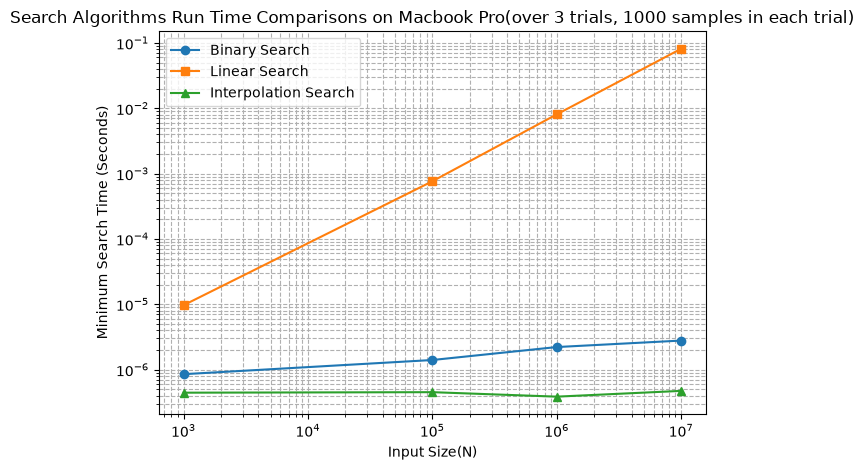

In [ ]:
# Most of this section was created with the help of Google Gemini AI

# Import pandas and matplotlib
import pandas as pd
import matplotlib.pyplot as plt

# Read results that were stored in .csv file
df = pd.read_csv('macbookPro_search_results.csv')

# Store data in columns 
df_pivoted = df.pivot(index = 'N', columns = 'Algorithm', values = 'Minimum Search Time')

# Ensure x-axis is using Input Size (N)
x = df_pivoted.index

# Plot each search algorithm with distinct markers
plt.plot(x, df_pivoted['Binary Search'], marker='o', label='Binary Search')
plt.plot(x, df_pivoted['Linear Search'], marker='s', label='Linear Search')
plt.plot(x, df_pivoted['Interpolation Search'], marker='^', label='Interpolation Search')

# Ensure log scale
plt.xscale('log')
plt.yscale('log')

# Set up titles and describe graph
plt.title('Search Algorithms Run Time Comparisons on Macbook Pro(over 3 trials, 1000 samples in each trial)')
plt.xlabel('Input Size(N)')
plt.ylabel('Minimum Search Time (Seconds)')
plt.legend(loc='upper left')
# Grid lines
plt.grid(True, which = "both", ls = "--")
# Adjusts spacing so labels don't get cut off
plt.tight_layout()  
# Show graph
plt.show()

### Linux Results

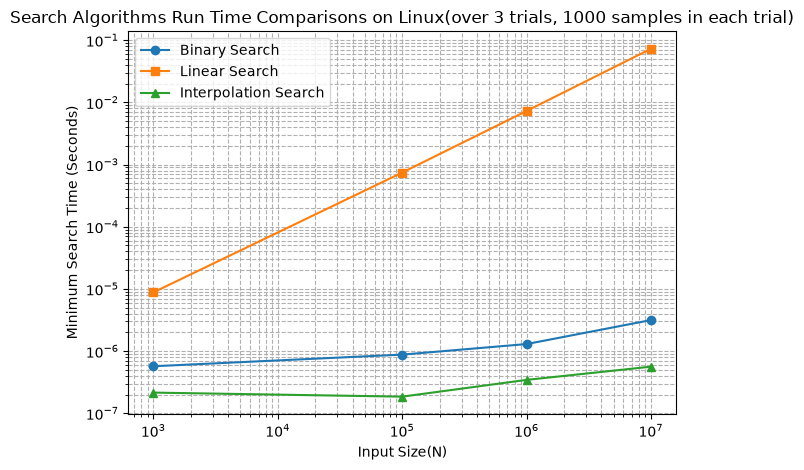

In [ ]:
# Most of this section was created with the help of Google Gemini AI

# Import pandas and matplotlib
import pandas as pd
import matplotlib.pyplot as plt

# Read results that were stored in .csv file
df = pd.read_csv('Linux_search_results.csv')

# Store data in columns 
df_pivoted = df.pivot(index = 'N', columns = 'Algorithm', values = 'Minimum Search Time')

# Ensure x-axis is using Input Size (N)
x = df_pivoted.index

# Plot each search algorithm with distinct markers
plt.plot(x, df_pivoted['Binary Search'], marker='o', label='Binary Search')
plt.plot(x, df_pivoted['Linear Search'], marker='s', label='Linear Search')
plt.plot(x, df_pivoted['Interpolation Search'], marker='^', label='Interpolation Search')

# Ensure log scale
plt.xscale('log')
plt.yscale('log')

# Descriptive features of Graph
plt.title('Search Algorithms Run Time Comparisons on Linux(over 3 trials, 1000 samples in each trial)')
plt.xlabel('Input Size(N)')
plt.ylabel('Minimum Search Time (Seconds)')
plt.legend(loc='upper left')
# Grid lines
plt.grid(True, which = "both", ls = "--")
# Adjusts spacing so labels don't get cut off
plt.tight_layout()  
# Show graph
plt.show()